In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (
    load_breast_cancer,
    load_wine,
    make_classification
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil diimpor!")

Library berhasil diimpor!


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (
    load_breast_cancer,
    load_wine,
    make_classification
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil diimpor!")

Library berhasil diimpor!


# Pertemuan 4: Classification - Logistic Regression & Decision Tree

## Tujuan
Mempelajari Logistic Regression dan Decision Tree untuk melakukan klasifikasi serta mengevaluasi performa model menggunakan berbagai metrik.

In [21]:
data = load_breast_cancer()

X = data.data
y = data.target

df_breast = pd.DataFrame(X, columns=data.feature_names)
df_breast['target'] = y

print("=== Informasi Dataset Breast Cancer ===")
print(f"Jumlah data   : {X.shape[0]}")
print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Nama kelas    : {data.target_names}")

display(df_breast.head())

=== Informasi Dataset Breast Cancer ===
Jumlah data   : 569
Jumlah fitur  : 30
Nama kelas    : ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [22]:
print("=== Distribusi Kelas ===")
print(df_breast['target'].value_counts())

print("\n=== Missing Value ===")
print(df_breast.isnull().sum().sum())

print("\n=== Statistik Dataset ===")
display(df_breast.describe())

=== Distribusi Kelas ===
target
1    357
0    212
Name: count, dtype: int64

=== Missing Value ===
0

=== Statistik Dataset ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


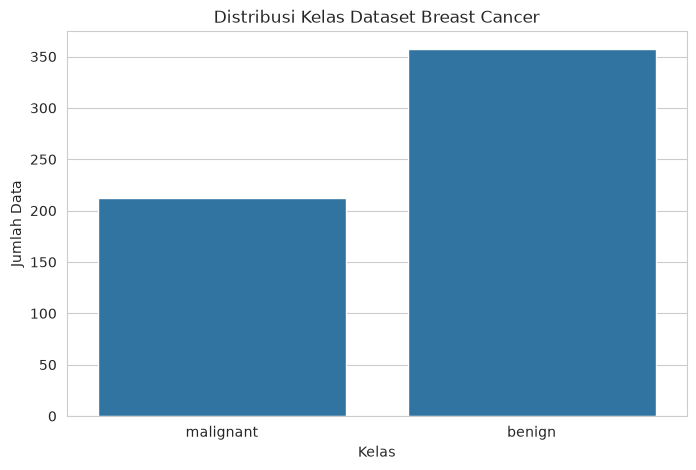

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=df_breast['target']
)

plt.xticks(
    [0, 1],
    [data.target_names[0], data.target_names[1]]
)

plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Kelas Dataset Breast Cancer')

plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== Pembagian Data ===")
print(f"Data training : {X_train.shape[0]}")
print(f"Data testing  : {X_test.shape[0]}")

=== Pembagian Data ===
Data training : 455
Data testing  : 114


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi data berhasil!")

Standardisasi data berhasil!


In [26]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression berhasil dilatih!")

Logistic Regression berhasil dilatih!


In [27]:
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)

print("Prediksi berhasil!")
print("\n5 Prediksi pertama :", y_pred[:5])
print("5 Probabilitas pertama:")
print(y_pred_proba[:5])

Prediksi berhasil!

5 Prediksi pertama : [0 1 0 1 0]
5 Probabilitas pertama:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Logistic Regression - Breast Cancer ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

=== Logistic Regression - Breast Cancer ===
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



=== Confusion Matrix ===
[[41  1]
 [ 1 71]]


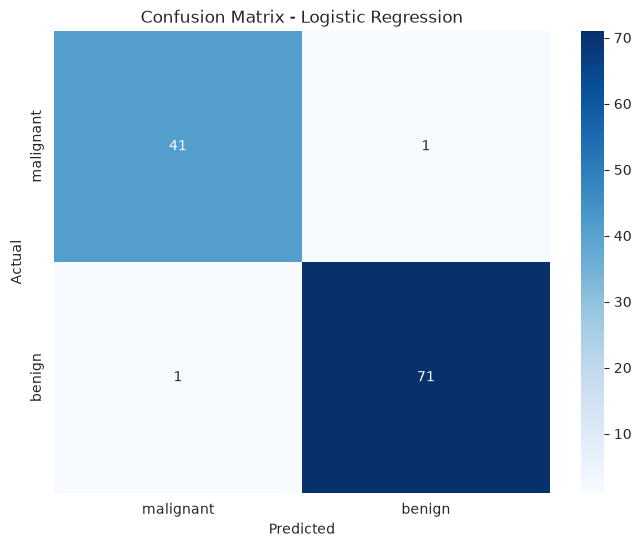

In [29]:
cm = confusion_matrix(y_test, y_pred)

print("=== Confusion Matrix ===")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

AUC: 0.9954


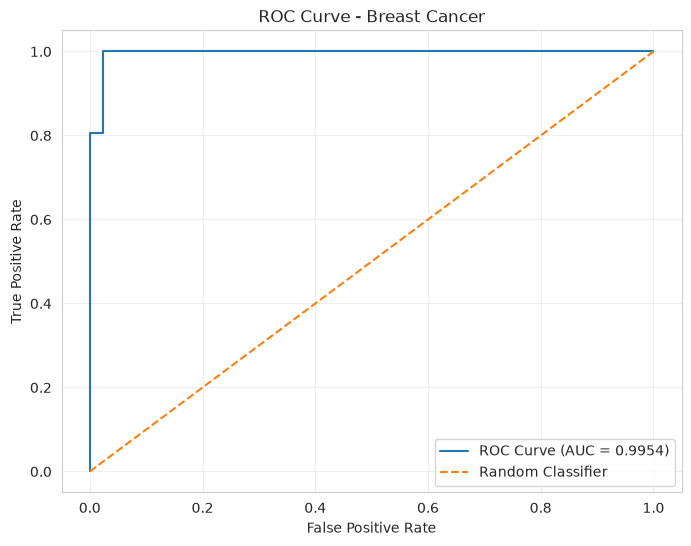

In [30]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba[:, 1]
)

roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Breast Cancer')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
correlation_target = df_breast.corr(numeric_only=True)['target'].drop('target')

best_features = (
    correlation_target.abs()
    .sort_values(ascending=False)
    .head(2)
    .index
    .tolist()
)

print("2 fitur terbaik:")
print(best_features)

X_2d = df_breast[best_features].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

lr_2d = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_2d.fit(X_train_2d_scaled, y_train_2d)

print("Model 2 fitur berhasil dibuat!")

2 fitur terbaik:
['worst concave points', 'worst perimeter']
Model 2 fitur berhasil dibuat!


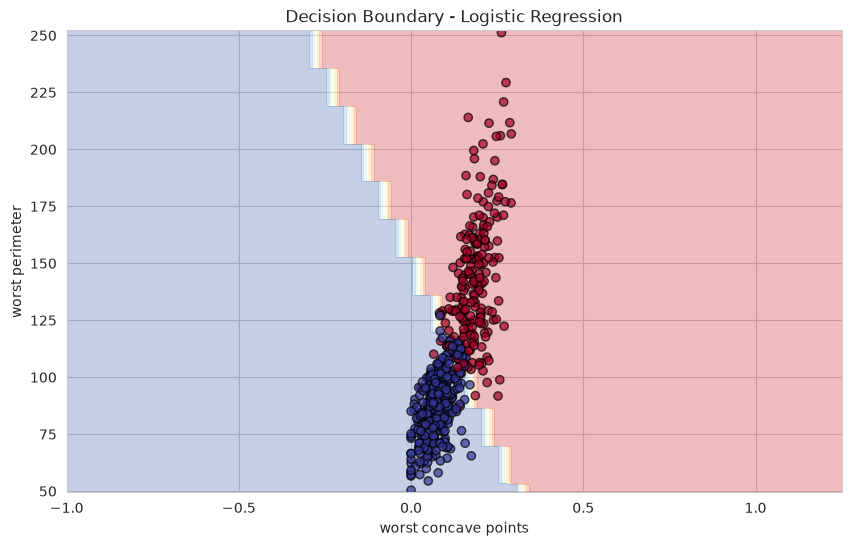

In [32]:
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

mesh = np.c_[xx.ravel(), yy.ravel()]
mesh_scaled = scaler_2d.transform(mesh)

Z = lr_2d.predict(mesh_scaled)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap='RdYlBu'
)

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    cmap='RdYlBu',
    edgecolors='k',
    alpha=0.7
)

plt.xlabel(best_features[0])
plt.ylabel(best_features[1])
plt.title('Decision Boundary - Logistic Regression')
plt.show()

## Interpretasi Tugas 1

Logistic Regression mampu melakukan klasifikasi dataset Breast Cancer dengan performa yang baik. Accuracy, precision, recall, dan F1-score digunakan untuk melihat kemampuan model dalam membedakan dua kelas.

Pada kasus breast cancer, recall sangat penting karena menunjukkan seberapa banyak kasus positif yang berhasil terdeteksi. Recall yang tinggi penting untuk mengurangi kemungkinan kasus kanker terlewat atau diklasifikasikan sebagai bukan kanker. Precision juga penting agar prediksi positif tidak terlalu banyak menghasilkan kesalahan.

ROC Curve dan nilai AUC digunakan untuk melihat kemampuan model dalam membedakan kedua kelas pada berbagai threshold. Semakin mendekati 1 nilai AUC, semakin baik kemampuan model dalam melakukan klasifikasi.

In [33]:
wine = load_wine()

X_wine = wine.data
y_wine = wine.target

df_wine = pd.DataFrame(
    X_wine,
    columns=wine.feature_names
)

df_wine['target'] = y_wine

print("=== Informasi Dataset Wine ===")
print(f"Jumlah data  : {X_wine.shape[0]}")
print(f"Jumlah fitur : {X_wine.shape[1]}")
print(f"Nama kelas   : {wine.target_names}")

display(df_wine.head())

=== Informasi Dataset Wine ===
Jumlah data  : 178
Jumlah fitur : 13
Nama kelas   : ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


=== Distribusi Kelas ===
target
0    59
1    71
2    48
Name: count, dtype: int64


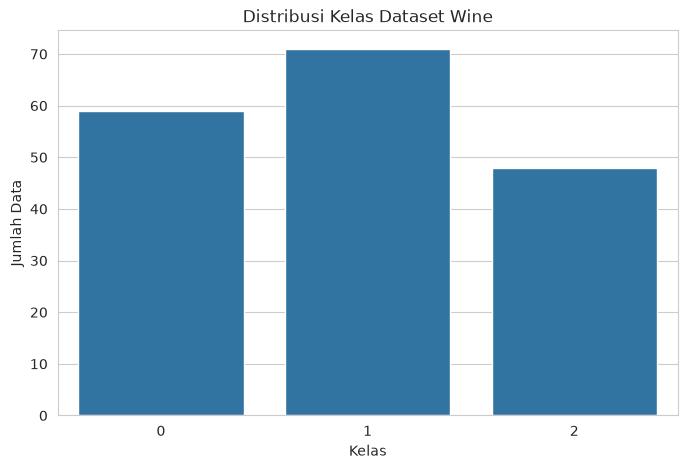

In [34]:
print("=== Distribusi Kelas ===")
print(df_wine['target'].value_counts().sort_index())

plt.figure(figsize=(8, 5))

sns.countplot(
    x=df_wine['target']
)

plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Kelas Dataset Wine')
plt.show()

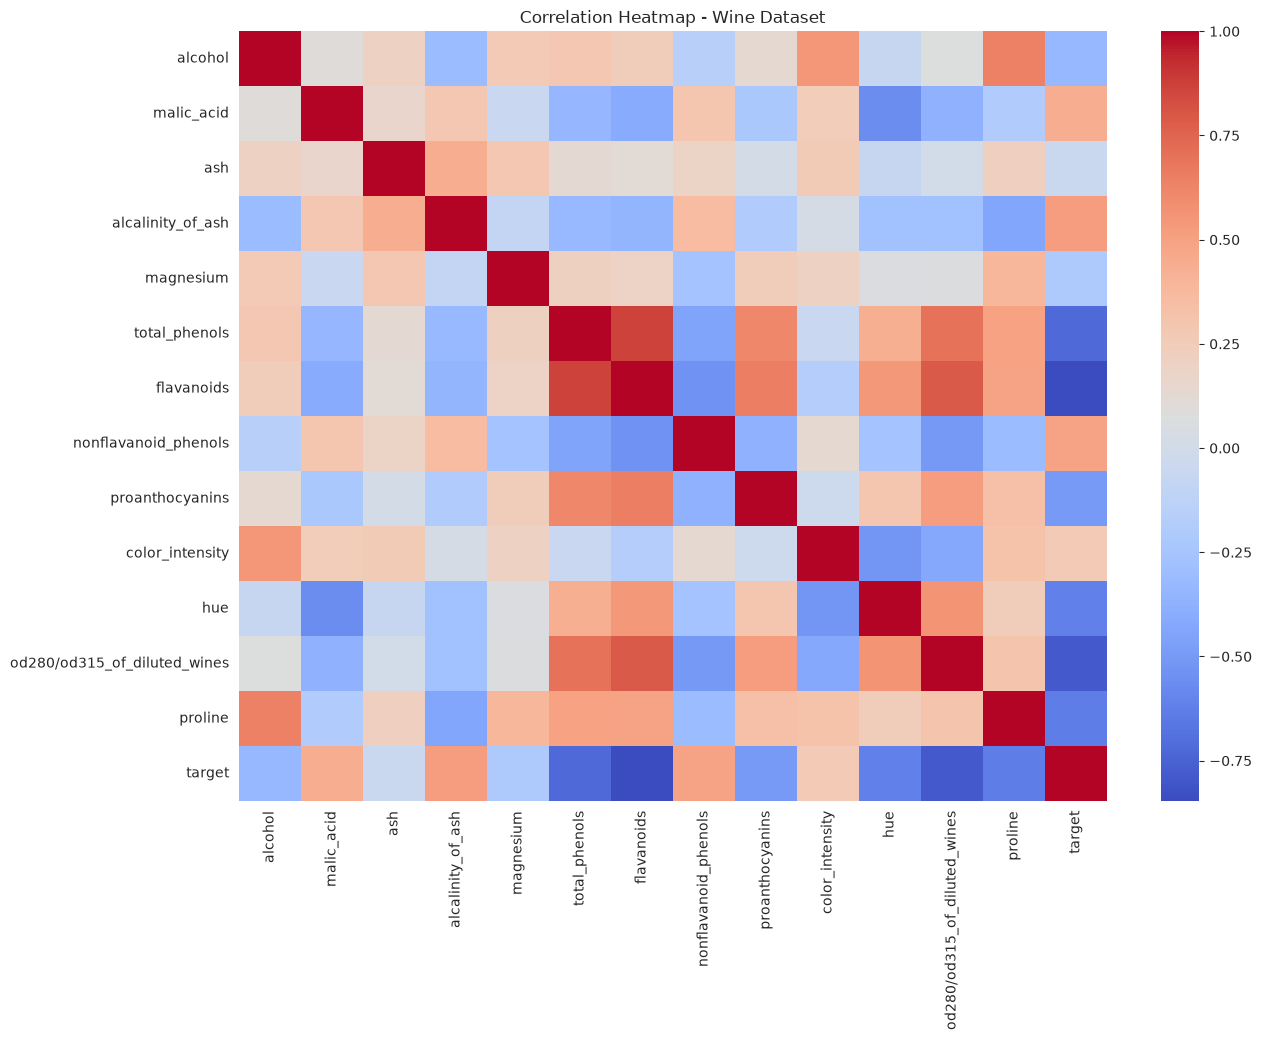

In [35]:
correlation_wine = df_wine.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_wine,
    annot=False,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap - Wine Dataset')
plt.show()

In [36]:
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine
)

scaler_wine = StandardScaler()

X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

print("=== Pembagian Data ===")
print(f"Data training : {X_train_wine.shape[0]}")
print(f"Data testing  : {X_test_wine.shape[0]}")
print("Standardisasi berhasil!")

=== Pembagian Data ===
Data training : 142
Data testing  : 36
Standardisasi berhasil!


In [37]:
lr_wine = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_wine.fit(
    X_train_wine_scaled,
    y_train_wine
)

y_pred_lr_wine = lr_wine.predict(X_test_wine_scaled)

accuracy_lr_wine = accuracy_score(
    y_test_wine,
    y_pred_lr_wine
)

precision_lr_wine = precision_score(
    y_test_wine,
    y_pred_lr_wine,
    average='weighted'
)

recall_lr_wine = recall_score(
    y_test_wine,
    y_pred_lr_wine,
    average='weighted'
)

f1_lr_wine = f1_score(
    y_test_wine,
    y_pred_lr_wine,
    average='weighted'
)

print("=== Logistic Regression - Wine ===")
print(f"Accuracy  : {accuracy_lr_wine:.4f}")
print(f"Precision : {precision_lr_wine:.4f}")
print(f"Recall    : {recall_lr_wine:.4f}")
print(f"F1-Score  : {f1_lr_wine:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_test_wine,
        y_pred_lr_wine,
        target_names=wine.target_names
    )
)

=== Logistic Regression - Wine ===
Accuracy  : 0.9722
Precision : 0.9741
Recall    : 0.9722
F1-Score  : 0.9720

=== Classification Report ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [38]:
dt_wine = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_wine.fit(
    X_train_wine,
    y_train_wine
)

y_pred_dt_wine = dt_wine.predict(X_test_wine)

print("Decision Tree berhasil dilatih!")

Decision Tree berhasil dilatih!


In [39]:
accuracy_dt_wine = accuracy_score(
    y_test_wine,
    y_pred_dt_wine
)

precision_dt_wine = precision_score(
    y_test_wine,
    y_pred_dt_wine,
    average='weighted'
)

recall_dt_wine = recall_score(
    y_test_wine,
    y_pred_dt_wine,
    average='weighted'
)

f1_dt_wine = f1_score(
    y_test_wine,
    y_pred_dt_wine,
    average='weighted'
)

print("=== Decision Tree - Wine ===")
print(f"Accuracy  : {accuracy_dt_wine:.4f}")
print(f"Precision : {precision_dt_wine:.4f}")
print(f"Recall    : {recall_dt_wine:.4f}")
print(f"F1-Score  : {f1_dt_wine:.4f}")

print("\n=== Classification Report ===")
print(
    classification_report(
        y_test_wine,
        y_pred_dt_wine,
        target_names=wine.target_names
    )
)

=== Decision Tree - Wine ===
Accuracy  : 0.9444
Precision : 0.9514
Recall    : 0.9444
F1-Score  : 0.9450

=== Classification Report ===
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



=== Confusion Matrix ===
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


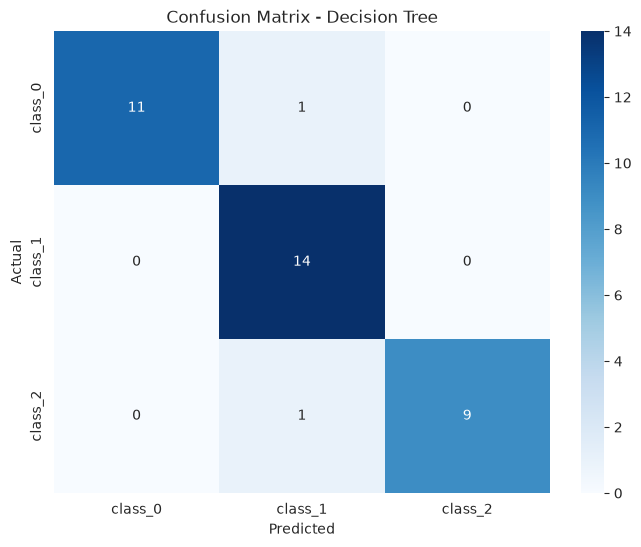

In [40]:
cm_dt_wine = confusion_matrix(
    y_test_wine,
    y_pred_dt_wine
)

print("=== Confusion Matrix ===")
print(cm_dt_wine)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_dt_wine,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

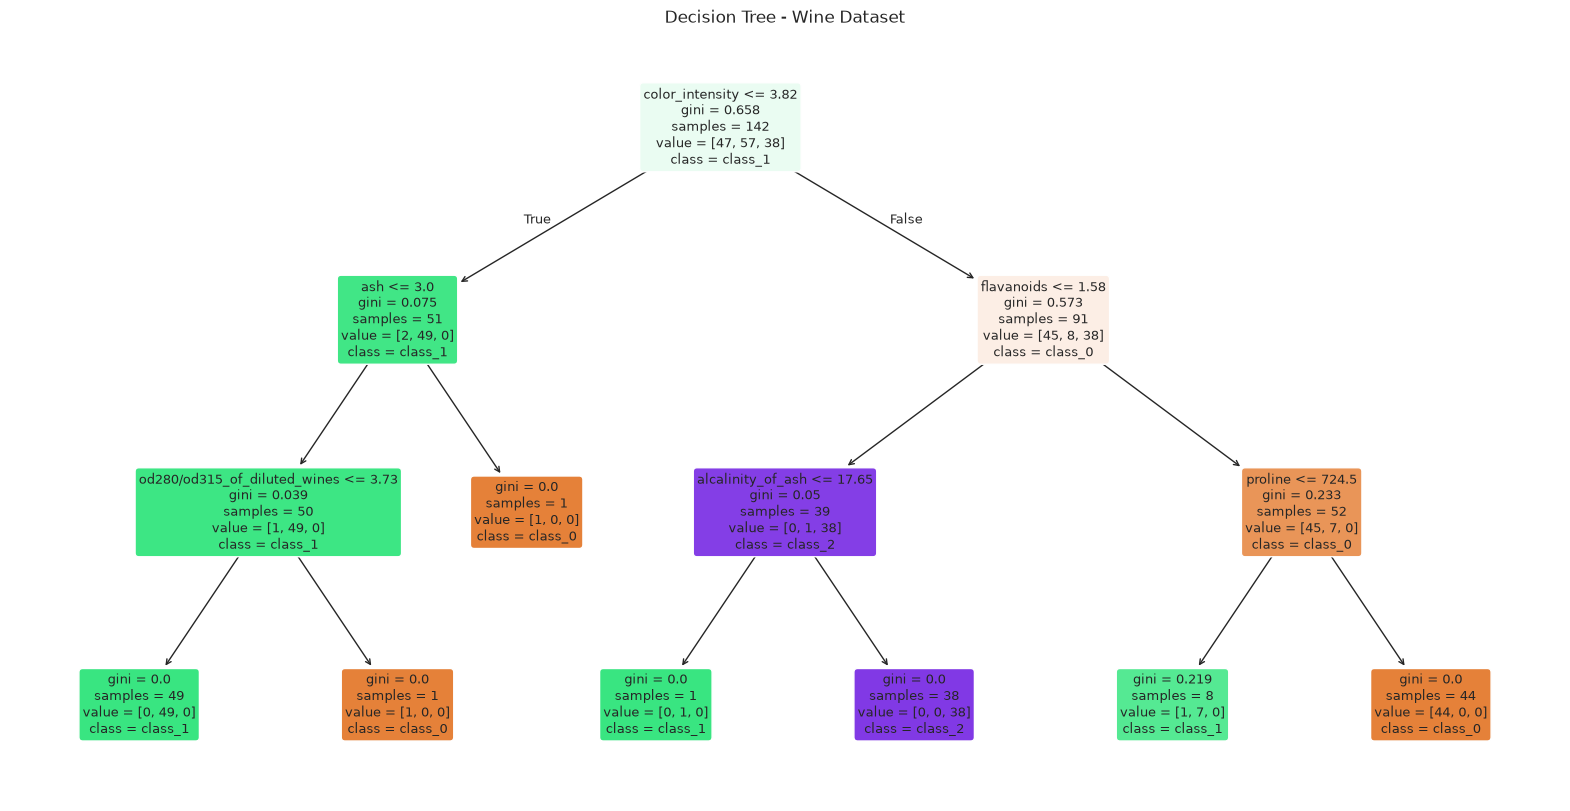

In [41]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_wine,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Decision Tree - Wine Dataset')
plt.show()

=== Feature Importance ===


,Feature,Importance
6,flavanoids,0.415865
9,color_intensity,0.407831
12,proline,0.113104
11,od280/od315_of_diluted_wines,0.021387
3,alcalinity_of_ash,0.021264
2,ash,0.020548
4,magnesium,0.000000
0,alcohol,0.000000
1,malic_acid,0.000000
8,proanthocyanins,0.000000


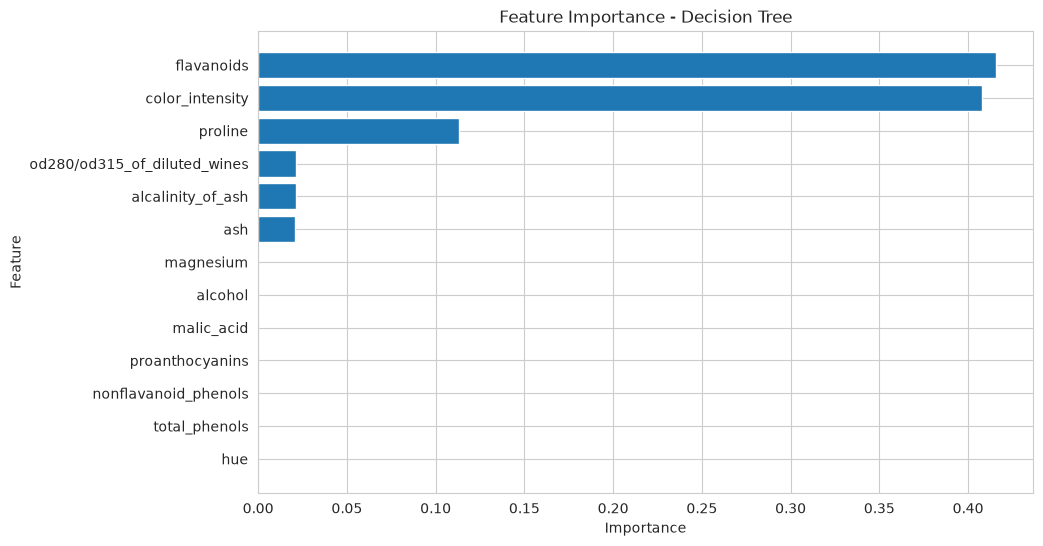

In [42]:
feature_importance = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': dt_wine.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("=== Feature Importance ===")
display(feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Decision Tree')
plt.gca().invert_yaxis()

plt.show()

In [43]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_lr_wine,
        accuracy_dt_wine
    ],
    'Precision': [
        precision_lr_wine,
        precision_dt_wine
    ],
    'Recall': [
        recall_lr_wine,
        recall_dt_wine
    ],
    'F1-Score': [
        f1_lr_wine,
        f1_dt_wine
    ]
})

print("=== Perbandingan Model ===")
display(comparison)

=== Perbandingan Model ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972222,0.974074,0.972222,0.971970
1,Decision Tree,0.944444,0.951389,0.944444,0.944961


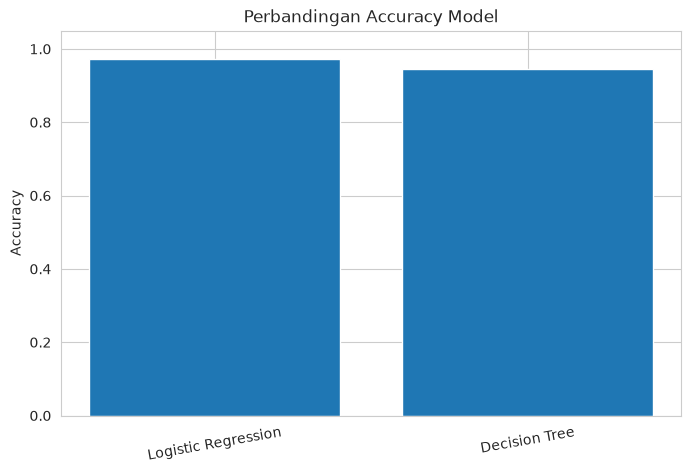

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Perbandingan Accuracy Model')
plt.xticks(rotation=10)

plt.show()

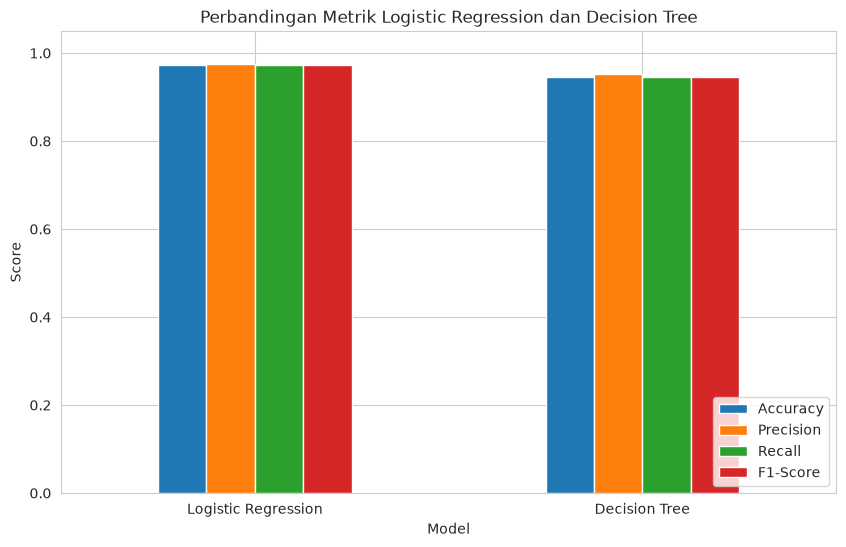

In [45]:
comparison_metrics = comparison.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
]

comparison_metrics.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Perbandingan Metrik Logistic Regression dan Decision Tree')
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

In [46]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print("=== Model Terbaik ===")
print(f"Model    : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")
print(f"F1-Score : {best_model['F1-Score']:.4f}")

=== Model Terbaik ===
Model    : Logistic Regression
Accuracy : 0.9722
F1-Score : 0.9720


## Kesimpulan Tugas 2

Berdasarkan hasil pengujian pada dataset Wine, Logistic Regression memperoleh accuracy sebesar 97,22%, sedangkan Decision Tree memperoleh accuracy sebesar 94,44%. Dengan demikian, Logistic Regression memberikan performa yang lebih baik pada dataset ini. Decision Tree tetap memiliki kelebihan karena hasilnya lebih mudah dipahami melalui struktur pohon dan feature importance.

In [47]:
depths = range(1, 21)

train_accuracies = []
test_accuracies = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train_wine, y_train_wine)
    
    train_pred = model.predict(X_train_wine)
    test_pred = model.predict(X_test_wine)
    
    train_accuracies.append(
        accuracy_score(y_train_wine, train_pred)
    )
    
    test_accuracies.append(
        accuracy_score(y_test_wine, test_pred)
    )

print("Pengujian max_depth 1-20 selesai!")

Pengujian max_depth 1-20 selesai!


In [48]:
depth_results = pd.DataFrame({
    'max_depth': list(depths),
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies
})

display(depth_results)

,max_depth,Train Accuracy,Test Accuracy
0,1,0.661972,0.583333
1,2,0.936620,0.861111
2,3,0.992958,0.944444
3,4,1.000000,0.944444
4,5,1.000000,0.944444
5,6,1.000000,0.944444
6,7,1.000000,0.944444
7,8,1.000000,0.944444
8,9,1.000000,0.944444
9,10,1.000000,0.944444


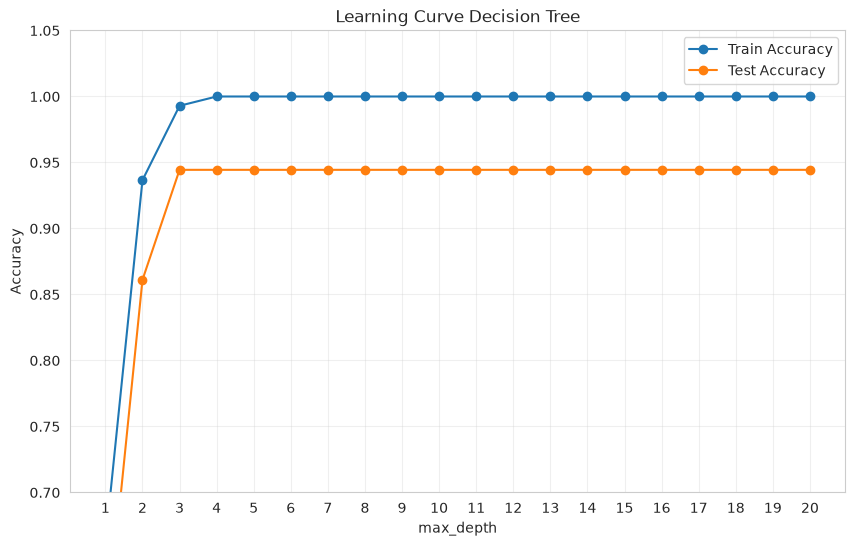

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    depths,
    test_accuracies,
    marker='o',
    label='Test Accuracy'
)

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Learning Curve Decision Tree')
plt.xticks(list(depths))
plt.ylim(0.7, 1.05)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [50]:
best_index = np.argmax(test_accuracies)

best_depth = list(depths)[best_index]
best_test_accuracy = test_accuracies[best_index]

print("=== Depth Terbaik ===")
print(f"max_depth terbaik : {best_depth}")
print(f"Test Accuracy     : {best_test_accuracy:.4f}")

=== Depth Terbaik ===
max_depth terbaik : 3
Test Accuracy     : 0.9444


In [51]:
print("=== Analisis Overfitting ===")

for depth, train_acc, test_acc in zip(
    depths,
    train_accuracies,
    test_accuracies
):
    if train_acc - test_acc >= 0.05:
        print(
            f"Overfitting mulai terlihat pada max_depth "
            f"{depth} "
            f"(Train={train_acc:.4f}, Test={test_acc:.4f})"
        )
        break
else:
    print("Perbedaan train dan test belum mencapai 0.05.")

=== Analisis Overfitting ===
Overfitting mulai terlihat pada max_depth 1 (Train=0.6620, Test=0.5833)


In [52]:
print("=== Analisis Overfitting ===")

for i in range(1, len(depths)):
    previous_test = test_accuracies[i - 1]
    current_test = test_accuracies[i]
    current_train = train_accuracies[i]
    
    if current_train > 0.95 and current_test < previous_test:
        print(
            f"Overfitting mulai terlihat sekitar max_depth "
            f"{depths[i]}"
        )
        print(f"Train Accuracy : {current_train:.4f}")
        print(f"Test Accuracy  : {current_test:.4f}")
        break
else:
    print("Overfitting kuat belum terlihat pada rentang max_depth 1-20.")

=== Analisis Overfitting ===
Overfitting kuat belum terlihat pada rentang max_depth 1-20.


In [53]:
best_rows = depth_results.sort_values(
    by='Test Accuracy',
    ascending=False
).head(5)

print("=== 5 Depth Terbaik ===")
display(best_rows)

=== 5 Depth Terbaik ===


,max_depth,Train Accuracy,Test Accuracy
3,4,1.000000,0.944444
2,3,0.992958,0.944444
5,6,1.000000,0.944444
4,5,1.000000,0.944444
12,13,1.000000,0.944444


In [54]:
best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_dt.fit(X_train_wine, y_train_wine)

y_pred_best_dt = best_dt.predict(X_test_wine)

best_dt_accuracy = accuracy_score(
    y_test_wine,
    y_pred_best_dt
)

print("=== Perbandingan Model ===")
print(f"Logistic Regression : {accuracy_lr_wine:.4f}")
print(f"Decision Tree       : {best_dt_accuracy:.4f}")
print(f"Decision Tree depth : {best_depth}")

=== Perbandingan Model ===
Logistic Regression : 0.9722
Decision Tree       : 0.9444
Decision Tree depth : 3


## Kesimpulan Tugas 3

Pengujian Decision Tree dengan max_depth 1 sampai 20 menunjukkan bahwa max_depth 3 memberikan Test Accuracy terbaik, yaitu 94,44%. Depth yang terlalu kecil dapat menyebabkan underfitting karena model terlalu sederhana. Sebaliknya, depth yang terlalu besar dapat menyebabkan overfitting karena model terlalu mengikuti data training. Pada dataset Wine ini, max_depth 3 menjadi pilihan yang baik karena memberikan performa testing yang paling tinggi.

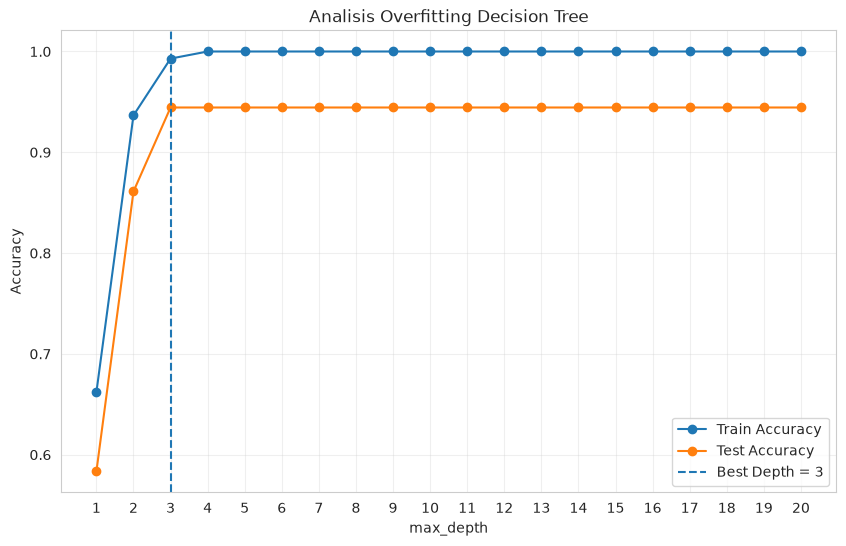

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    depths,
    test_accuracies,
    marker='o',
    label='Test Accuracy'
)

plt.axvline(
    best_depth,
    linestyle='--',
    label=f'Best Depth = {best_depth}'
)

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Analisis Overfitting Decision Tree')
plt.xticks(list(depths))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [56]:
print("=== Analisis Train vs Test ===")

for depth, train_acc, test_acc in zip(
    depths,
    train_accuracies,
    test_accuracies
):
    print(
        f"Depth {depth:2d} | "
        f"Train: {train_acc:.4f} | "
        f"Test: {test_acc:.4f}"
    )

=== Analisis Train vs Test ===
Depth  1 | Train: 0.6620 | Test: 0.5833
Depth  2 | Train: 0.9366 | Test: 0.8611
Depth  3 | Train: 0.9930 | Test: 0.9444
Depth  4 | Train: 1.0000 | Test: 0.9444
Depth  5 | Train: 1.0000 | Test: 0.9444
Depth  6 | Train: 1.0000 | Test: 0.9444
Depth  7 | Train: 1.0000 | Test: 0.9444
Depth  8 | Train: 1.0000 | Test: 0.9444
Depth  9 | Train: 1.0000 | Test: 0.9444
Depth 10 | Train: 1.0000 | Test: 0.9444
Depth 11 | Train: 1.0000 | Test: 0.9444
Depth 12 | Train: 1.0000 | Test: 0.9444
Depth 13 | Train: 1.0000 | Test: 0.9444
Depth 14 | Train: 1.0000 | Test: 0.9444
Depth 15 | Train: 1.0000 | Test: 0.9444
Depth 16 | Train: 1.0000 | Test: 0.9444
Depth 17 | Train: 1.0000 | Test: 0.9444
Depth 18 | Train: 1.0000 | Test: 0.9444
Depth 19 | Train: 1.0000 | Test: 0.9444
Depth 20 | Train: 1.0000 | Test: 0.9444


## Kesimpulan Tugas 3

Berdasarkan pengujian max_depth 1 sampai 20, Decision Tree memperoleh Test Accuracy tertinggi sebesar 94,44%. Nilai tersebut muncul pada beberapa depth, dan max_depth 3 dipilih karena model masih relatif sederhana serta sudah memberikan performa testing yang tinggi.

Pada depth yang kecil, model dapat mengalami underfitting karena struktur pohon terlalu sederhana. Ketika depth semakin besar, akurasi training dapat mencapai 100%, tetapi akurasi testing tidak mengalami peningkatan. Hal ini menunjukkan bahwa model mulai terlalu menyesuaikan diri dengan data training.

Jika dibandingkan dengan Logistic Regression yang memiliki accuracy 97,22%, Logistic Regression masih memberikan performa yang lebih baik pada dataset Wine.

In [57]:
# Membuat dataset customer churn sederhana

data_custom = {
    'umur': [
        22, 25, 28, 31, 35, 40, 45, 50, 23, 27,
        33, 38, 42, 48, 52, 29, 36, 44, 26, 39,
        47, 54, 30, 34, 41, 49, 24, 37, 43, 51
    ],
    'lama_berlangganan': [
        2, 4, 6, 8, 12, 24, 30, 36, 3, 5,
        10, 18, 20, 32, 40, 7, 14, 28, 4, 16,
        25, 42, 9, 11, 22, 35, 2, 15, 27, 38
    ],
    'jenis_layanan': [
        'Basic', 'Basic', 'Premium', 'Premium', 'Premium',
        'Premium', 'Basic', 'Premium', 'Basic', 'Basic',
        'Premium', 'Premium', 'Basic', 'Premium', 'Premium',
        'Basic', 'Premium', 'Premium', 'Basic', 'Premium',
        'Basic', 'Premium', 'Basic', 'Premium', 'Basic',
        'Premium', 'Basic', 'Premium', 'Basic', 'Premium'
    ],
    'keluhan': [
        5, 4, 3, 2, 1, 0, 1, 0, 6, 5,
        2, 1, 4, 0, 1, 4, 2, 0, 6, 2,
        3, 0, 5, 1, 3, 0, 7, 2, 4, 1
    ],
    'churn': [
        'Ya', 'Ya', 'Tidak', 'Tidak', 'Tidak',
        'Tidak', 'Tidak', 'Tidak', 'Ya', 'Ya',
        'Tidak', 'Tidak', 'Ya', 'Tidak', 'Tidak',
        'Ya', 'Tidak', 'Tidak', 'Ya', 'Tidak',
        'Ya', 'Tidak', 'Ya', 'Tidak', 'Ya',
        'Tidak', 'Ya', 'Tidak', 'Ya', 'Tidak'
    ]
}

df_custom = pd.DataFrame(data_custom)

# Tambahkan beberapa missing value
df_custom.loc[4, 'umur'] = np.nan
df_custom.loc[12, 'keluhan'] = np.nan
df_custom.loc[18, 'jenis_layanan'] = np.nan

print("=== Custom Dataset ===")
display(df_custom.head(10))

print(f"Jumlah data: {len(df_custom)}")

=== Custom Dataset ===


,umur,lama_berlangganan,jenis_layanan,keluhan,churn
0,22.0,2,Basic,5.0,Ya
1,25.0,4,Basic,4.0,Ya
2,28.0,6,Premium,3.0,Tidak
3,31.0,8,Premium,2.0,Tidak
4,NaN,12,Premium,1.0,Tidak
5,40.0,24,Premium,0.0,Tidak
6,45.0,30,Basic,1.0,Tidak
7,50.0,36,Premium,0.0,Tidak
8,23.0,3,Basic,6.0,Ya
9,27.0,5,Basic,5.0,Ya


Jumlah data: 30


In [58]:
print("=== Informasi Dataset ===")
print(df_custom.info())

print("\n=== Missing Value ===")
print(df_custom.isnull().sum())

print("\n=== Distribusi Churn ===")
print(df_custom['churn'].value_counts())

=== Informasi Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   umur               29 non-null     float64
 1   lama_berlangganan  30 non-null     int64  
 2   jenis_layanan      29 non-null     str    
 3   keluhan            29 non-null     float64
 4   churn              30 non-null     str    
dtypes: float64(2), int64(1), str(2)
memory usage: 1.3 KB
None

=== Missing Value ===
umur                 1
lama_berlangganan    0
jenis_layanan        1
keluhan              1
churn                0
dtype: int64

=== Distribusi Churn ===
churn
Tidak    18
Ya       12
Name: count, dtype: int64


In [59]:
# Mengisi missing value pada fitur numerik
df_custom['umur'] = df_custom['umur'].fillna(
    df_custom['umur'].median()
)

df_custom['keluhan'] = df_custom['keluhan'].fillna(
    df_custom['keluhan'].median()
)

# Mengisi missing value pada fitur kategorikal
df_custom['jenis_layanan'] = df_custom['jenis_layanan'].fillna(
    df_custom['jenis_layanan'].mode()[0]
)

print("=== Missing Value Setelah Dibersihkan ===")
print(df_custom.isnull().sum())

display(df_custom.head())

=== Missing Value Setelah Dibersihkan ===
umur                 0
lama_berlangganan    0
jenis_layanan        0
keluhan              0
churn                0
dtype: int64


,umur,lama_berlangganan,jenis_layanan,keluhan,churn
0,22.0,2,Basic,5.0,Ya
1,25.0,4,Basic,4.0,Ya
2,28.0,6,Premium,3.0,Tidak
3,31.0,8,Premium,2.0,Tidak
4,38.0,12,Premium,1.0,Tidak


In [60]:
# Encoding fitur kategorikal
df_model = pd.get_dummies(
    df_custom,
    columns=['jenis_layanan'],
    drop_first=True,
    dtype=int
)

# Encoding target
df_model['churn'] = df_model['churn'].map({
    'Tidak': 0,
    'Ya': 1
})

print("=== Dataset Setelah Encoding ===")
display(df_model.head())

print("\nNama kolom:")
print(df_model.columns.tolist())

=== Dataset Setelah Encoding ===


,umur,lama_berlangganan,keluhan,churn,jenis_layanan_Premium
0,22.0,2,5.0,1,0
1,25.0,4,4.0,1,0
2,28.0,6,3.0,0,1
3,31.0,8,2.0,0,1
4,38.0,12,1.0,0,1



Nama kolom:
['umur', 'lama_berlangganan', 'keluhan', 'churn', 'jenis_layanan_Premium']


In [61]:
X_custom = df_model.drop('churn', axis=1)
y_custom = df_model['churn']

X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom,
    y_custom,
    test_size=0.2,
    random_state=42,
    stratify=y_custom
)

print("=== Pembagian Data Custom Dataset ===")
print(f"Data training : {len(X_train_custom)}")
print(f"Data testing  : {len(X_test_custom)}")
print(f"Jumlah fitur  : {X_custom.shape[1]}")

=== Pembagian Data Custom Dataset ===
Data training : 24
Data testing  : 6
Jumlah fitur  : 4


In [62]:
# Standardisasi fitur untuk Logistic Regression
scaler_custom = StandardScaler()

X_train_custom_scaled = scaler_custom.fit_transform(
    X_train_custom
)

X_test_custom_scaled = scaler_custom.transform(
    X_test_custom
)

lr_custom = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_custom.fit(
    X_train_custom_scaled,
    y_train_custom
)

y_pred_lr_custom = lr_custom.predict(
    X_test_custom_scaled
)

print("Logistic Regression berhasil dilatih!")

Logistic Regression berhasil dilatih!


In [63]:
accuracy_lr_custom = accuracy_score(
    y_test_custom,
    y_pred_lr_custom
)

precision_lr_custom = precision_score(
    y_test_custom,
    y_pred_lr_custom,
    zero_division=0
)

recall_lr_custom = recall_score(
    y_test_custom,
    y_pred_lr_custom,
    zero_division=0
)

f1_lr_custom = f1_score(
    y_test_custom,
    y_pred_lr_custom,
    zero_division=0
)

print("=== Logistic Regression - Custom Dataset ===")
print(f"Accuracy  : {accuracy_lr_custom:.4f}")
print(f"Precision : {precision_lr_custom:.4f}")
print(f"Recall    : {recall_lr_custom:.4f}")
print(f"F1-Score  : {f1_lr_custom:.4f}")

=== Logistic Regression - Custom Dataset ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [64]:
dt_custom = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_custom.fit(
    X_train_custom,
    y_train_custom
)

y_pred_dt_custom = dt_custom.predict(
    X_test_custom
)

print("Decision Tree berhasil dilatih!")

Decision Tree berhasil dilatih!


In [65]:
accuracy_dt_custom = accuracy_score(
    y_test_custom,
    y_pred_dt_custom
)

precision_dt_custom = precision_score(
    y_test_custom,
    y_pred_dt_custom,
    zero_division=0
)

recall_dt_custom = recall_score(
    y_test_custom,
    y_pred_dt_custom,
    zero_division=0
)

f1_dt_custom = f1_score(
    y_test_custom,
    y_pred_dt_custom,
    zero_division=0
)

print("=== Decision Tree - Custom Dataset ===")
print(f"Accuracy  : {accuracy_dt_custom:.4f}")
print(f"Precision : {precision_dt_custom:.4f}")
print(f"Recall    : {recall_dt_custom:.4f}")
print(f"F1-Score  : {f1_dt_custom:.4f}")

=== Decision Tree - Custom Dataset ===
Accuracy  : 0.8333
Precision : 1.0000
Recall    : 0.5000
F1-Score  : 0.6667


In [66]:
custom_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_lr_custom,
        accuracy_dt_custom
    ],
    'Precision': [
        precision_lr_custom,
        precision_dt_custom
    ],
    'Recall': [
        recall_lr_custom,
        recall_dt_custom
    ],
    'F1-Score': [
        f1_lr_custom,
        f1_dt_custom
    ]
})

print("=== Perbandingan Model Custom Dataset ===")
display(custom_comparison)

=== Perbandingan Model Custom Dataset ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.0,1.0,1.000000
1,Decision Tree,0.833333,1.0,0.5,0.666667


=== Confusion Matrix Logistic Regression ===
[[4 0]
 [0 2]]


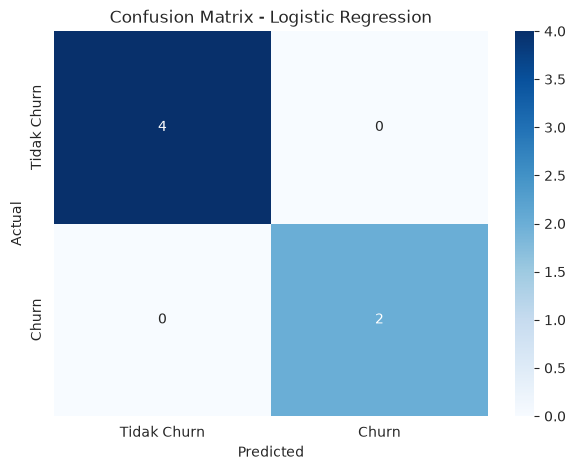

In [67]:
cm_lr_custom = confusion_matrix(
    y_test_custom,
    y_pred_lr_custom
)

print("=== Confusion Matrix Logistic Regression ===")
print(cm_lr_custom)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr_custom,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Churn', 'Churn'],
    yticklabels=['Tidak Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

=== Confusion Matrix Decision Tree ===
[[4 0]
 [1 1]]


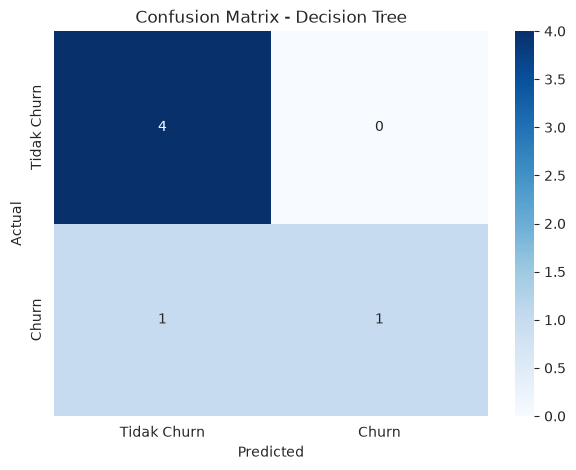

In [68]:
cm_dt_custom = confusion_matrix(
    y_test_custom,
    y_pred_dt_custom
)

print("=== Confusion Matrix Decision Tree ===")
print(cm_dt_custom)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt_custom,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Churn', 'Churn'],
    yticklabels=['Tidak Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

=== Feature Importance Decision Tree ===


,Feature,Importance
2,keluhan,0.92987
3,jenis_layanan_Premium,0.07013
1,lama_berlangganan,0.00000
0,umur,0.00000


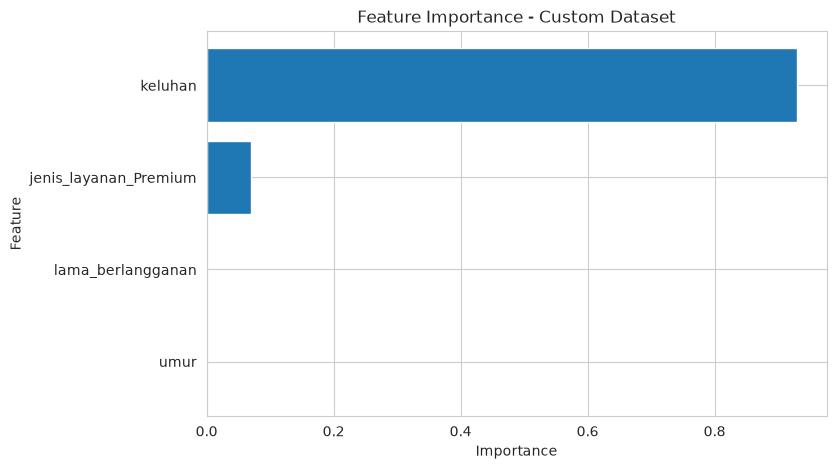

In [69]:
custom_importance = pd.DataFrame({
    'Feature': X_custom.columns,
    'Importance': dt_custom.feature_importances_
})

custom_importance = custom_importance.sort_values(
    by='Importance',
    ascending=False
)

print("=== Feature Importance Decision Tree ===")
display(custom_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    custom_importance['Feature'],
    custom_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Custom Dataset')
plt.gca().invert_yaxis()

plt.show()

## Kesimpulan Tugas 4

Pada custom dataset customer churn, dilakukan preprocessing berupa penanganan missing value dan encoding data kategorikal. Dua model yang digunakan adalah Logistic Regression dan Decision Tree.

Logistic Regression memperoleh accuracy 100%, precision 100%, recall 100%, dan F1-score 100%. Sementara itu, Decision Tree memperoleh accuracy 83,33%, precision 100%, recall 50%, dan F1-score 66,67%.

Berdasarkan hasil tersebut, Logistic Regression menjadi model yang lebih baik untuk dataset ini karena mampu mendeteksi seluruh data pada data testing dengan benar. Model ini dapat digunakan untuk membantu memprediksi pelanggan yang berpotensi berhenti berlangganan.

In [70]:
print("=" * 60)
print("RINGKASAN HASIL PERTEMUAN 4")
print("=" * 60)

print("\nTUGAS 1 - BREAST CANCER")
print(f"Logistic Regression Accuracy : {accuracy:.4f}")
print(f"AUC                          : {roc_auc:.4f}")

print("\nTUGAS 2 - WINE")
print(f"Logistic Regression Accuracy : {accuracy_lr_wine:.4f}")
print(f"Decision Tree Accuracy       : {accuracy_dt_wine:.4f}")

print("\nTUGAS 3 - OVERFITTING")
print(f"Best max_depth               : {best_depth}")
print(f"Best Test Accuracy           : {best_test_accuracy:.4f}")

print("\nTUGAS 4 - CUSTOM DATASET")
print(f"Logistic Regression Accuracy : {accuracy_lr_custom:.4f}")
print(f"Decision Tree Accuracy       : {accuracy_dt_custom:.4f}")

RINGKASAN HASIL PERTEMUAN 4

TUGAS 1 - BREAST CANCER
Logistic Regression Accuracy : 0.9825
AUC                          : 0.9954

TUGAS 2 - WINE
Logistic Regression Accuracy : 0.9722
Decision Tree Accuracy       : 0.9444

TUGAS 3 - OVERFITTING
Best max_depth               : 3
Best Test Accuracy           : 0.9444

TUGAS 4 - CUSTOM DATASET
Logistic Regression Accuracy : 1.0000
Decision Tree Accuracy       : 0.8333


# Kesimpulan Pertemuan 4

Pada praktikum ini telah dipelajari metode klasifikasi menggunakan Logistic Regression dan Decision Tree. Logistic Regression berhasil digunakan untuk klasifikasi binary pada dataset Breast Cancer dan multiclass pada dataset Wine. Evaluasi dilakukan menggunakan accuracy, precision, recall, F1-score, confusion matrix, ROC Curve, dan AUC.

Pada dataset Breast Cancer, Logistic Regression memperoleh performa yang sangat baik dengan accuracy 98,25% dan AUC 99,54%. Pada dataset Wine, Logistic Regression memperoleh accuracy 97,22%, lebih tinggi dibandingkan Decision Tree sebesar 94,44%.

Analisis max_depth pada Decision Tree menunjukkan bahwa max_depth 3 memberikan Test Accuracy terbaik sebesar 94,44%. Depth yang terlalu kecil dapat menyebabkan underfitting, sedangkan depth yang terlalu besar dapat membuat model terlalu menyesuaikan data training.

Pada custom dataset customer churn, Logistic Regression memperoleh accuracy 100%, sedangkan Decision Tree memperoleh accuracy 83,33%. Berdasarkan seluruh percobaan, pemilihan model harus disesuaikan dengan karakteristik dataset dan tujuan klasifikasi.

In [71]:
print("=== CHECK AKHIR NOTEBOOK ===")

variables_check = [
    'df_breast',
    'df_wine',
    'df_custom',
    'lr_model',
    'lr_wine',
    'dt_wine',
    'lr_custom',
    'dt_custom'
]

for var in variables_check:
    if var in globals():
        print(f"✓ {var}")
    else:
        print(f"✗ {var} belum tersedia")

print("\nNotebook Pertemuan 4 selesai.")

=== CHECK AKHIR NOTEBOOK ===
✓ df_breast
✓ df_wine
✓ df_custom
✓ lr_model
✓ lr_wine
✓ dt_wine
✓ lr_custom
✓ dt_custom

Notebook Pertemuan 4 selesai.


## Informasi Pengumpulan

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning  

**Judul:** Pertemuan 4: Classification - Logistic Regression & Decision Tree

File notebook:
`pertemuan_04_classification.ipynb`

File PDF:
`105841113523_MUH_ALI_IMRAN_Pertemuan04.pdf`

# Checklist Pertemuan 4

- [x] Tugas 1 - Binary Classification Breast Cancer
- [x] Logistic Regression
- [x] Confusion Matrix
- [x] Accuracy, Precision, Recall, F1
- [x] ROC Curve dan AUC
- [x] Decision Boundary
- [x] Tugas 2 - Multi-class Classification Wine
- [x] Logistic Regression
- [x] Decision Tree
- [x] Perbandingan Model
- [x] Feature Importance
- [x] Visualisasi Decision Tree
- [x] Tugas 3 - Analisis Overfitting
- [x] max_depth 1-20
- [x] Learning Curve
- [x] Tugas 4 - Custom Dataset
- [x] Missing Value
- [x] Encoding
- [x] Logistic Regression
- [x] Decision Tree
- [x] Evaluasi dan Perbandingan
- [x] Kesimpulan